In [6]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import episcanpy as epi
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import glob
import sklearn
import pyreadr
import scipy
import os

from pathlib import Path
from helps import *

# Raw CM

## Peak

In [5]:
atac=sc.read_mtx("Datasets/MouseSkin/GSM4156597_skin.late.anagen.counts.txt.gz").T
atac.X=scipy.sparse.csr_matrix(atac.X, dtype="int32")
atac.var=pd.read_csv("Datasets/MouseSkin/GSM4156597_skin.late.anagen.peaks.bed.gz", sep="\t", header=None)
atac

AnnData object with n_obs × n_vars = 34774 × 344592
    var: 0, 1, 2

In [6]:
atac.obs.index=pd.read_csv("Datasets/MouseSkin/GSM4156597_skin.late.anagen.barcodes.txt.gz", sep="\t", header=None)[0]
atac.obs.index.name=""
atac.obs.head()

""
""
R1.01.R2.01.R3.06.P1.55
R1.01.R2.03.R3.68.P1.55
R1.01.R2.05.R3.15.P1.53
R1.01.R2.05.R3.40.P1.55
R1.01.R2.05.R3.49.P1.55


In [7]:
metadata=pd.read_csv("Datasets/MouseSkin/GSM4156597_skin_celltype.txt.gz", sep="\t")
print(metadata.shape)
metadata.index=metadata["rna.bc"]
metadata.head()

(34774, 3)


,atac.bc,rna.bc,celltype
rna.bc,,,
R1.01.R2.01.R3.06.P1.55,R1.01.R2.01.R3.06.P1.07,R1.01.R2.01.R3.06.P1.55,Dermal Fibroblast
R1.01.R2.03.R3.68.P1.55,R1.01.R2.03.R3.68.P1.07,R1.01.R2.03.R3.68.P1.55,Dermal Fibroblast
R1.01.R2.05.R3.15.P1.53,R1.01.R2.05.R3.15.P1.05,R1.01.R2.05.R3.15.P1.53,Dermal Fibroblast
R1.01.R2.05.R3.40.P1.55,R1.01.R2.05.R3.40.P1.07,R1.01.R2.05.R3.40.P1.55,Dermal Fibroblast
R1.01.R2.05.R3.49.P1.55,R1.01.R2.05.R3.49.P1.07,R1.01.R2.05.R3.49.P1.55,Dermal Fibroblast


In [8]:
atac.obs=metadata.loc[atac.obs.index]
atac.obs.index=atac.obs["atac.bc"]
atac.obs.index.name="barcode"
atac.obs.head()

,atac.bc,rna.bc,celltype
barcode,,,
R1.01.R2.01.R3.06.P1.07,R1.01.R2.01.R3.06.P1.07,R1.01.R2.01.R3.06.P1.55,Dermal Fibroblast
R1.01.R2.03.R3.68.P1.07,R1.01.R2.03.R3.68.P1.07,R1.01.R2.03.R3.68.P1.55,Dermal Fibroblast
R1.01.R2.05.R3.15.P1.05,R1.01.R2.05.R3.15.P1.05,R1.01.R2.05.R3.15.P1.53,Dermal Fibroblast
R1.01.R2.05.R3.40.P1.07,R1.01.R2.05.R3.40.P1.07,R1.01.R2.05.R3.40.P1.55,Dermal Fibroblast
R1.01.R2.05.R3.49.P1.07,R1.01.R2.05.R3.49.P1.07,R1.01.R2.05.R3.49.P1.55,Dermal Fibroblast


In [9]:
atac.var.index=atac.var[[0, 1, 2]].astype(str).agg('_'.join, axis=1)
atac.var.rename({0 : "chr", 1 : "start", 2 : "stop"}, axis=1, inplace=True)
atac.var.head()

,chr,start,stop
chrX_143482906_143483206,chrX,143482906,143483206
chr6_3200976_3201276,chr6,3200976,3201276
chr9_123461850_123462150,chr9,123461850,123462150
chr1_56782095_56782395,chr1,56782095,56782395
chr9_56223668_56223968,chr9,56223668,56223968


In [10]:
atac.obs["atac.bc"]=atac.obs["atac.bc"].str.replace(".", "_")
atac.obs["atac.bc"]=atac.obs["atac.bc"].str.replace(",", "_")
atac.obs["rna.bc"]=atac.obs["rna.bc"].str.replace(".", "_")
atac.obs["rna.bc"]=atac.obs["rna.bc"].str.replace(",", "_")
atac.obs.index=atac.obs.index.str.replace(".", "_")
atac.obs.index=atac.obs.index.str.replace(",", "_")
atac.obs

,atac.bc,rna.bc,celltype
barcode,,,
R1_01_R2_01_R3_06_P1_07,R1_01_R2_01_R3_06_P1_07,R1_01_R2_01_R3_06_P1_55,Dermal Fibroblast
R1_01_R2_03_R3_68_P1_07,R1_01_R2_03_R3_68_P1_07,R1_01_R2_03_R3_68_P1_55,Dermal Fibroblast
R1_01_R2_05_R3_15_P1_05,R1_01_R2_05_R3_15_P1_05,R1_01_R2_05_R3_15_P1_53,Dermal Fibroblast
R1_01_R2_05_R3_40_P1_07,R1_01_R2_05_R3_40_P1_07,R1_01_R2_05_R3_40_P1_55,Dermal Fibroblast
R1_01_R2_05_R3_49_P1_07,R1_01_R2_05_R3_49_P1_07,R1_01_R2_05_R3_49_P1_55,Dermal Fibroblast
...,...,...,...
R1_92_R2_79_R3_05_P1_08,R1_92_R2_79_R3_05_P1_08,R1_92_R2_79_R3_05_P1_56,Melanocyte
R1_93_R2_20_R3_18_P1_05,R1_93_R2_20_R3_18_P1_05,R1_93_R2_20_R3_18_P1_53,Melanocyte
R1_93_R2_80_R3_62_P1_07,R1_93_R2_80_R3_62_P1_07,R1_93_R2_80_R3_62_P1_55,Melanocyte


In [11]:
atac.obs.rename({"celltype" : "CellType"}, axis=1, inplace=True)

In [12]:
Path("Datasets/MouseSkin/CM").mkdir(parents=True, exist_ok=True)
atac.write("Datasets/MouseSkin/CM/MouseSkin_Peak_Raw.h5ad", compression="gzip")

## GEX

In [13]:
rna=sc.read("Datasets/MouseSkin/GSM4156608_skin.late.anagen.rna.counts.txt.gz").T
rna.X=scipy.sparse.csr_matrix(rna.X, dtype="int32")
rna

Only considering the two last: ['.txt', '.gz'].
Only considering the two last: ['.txt', '.gz'].


AnnData object with n_obs × n_vars = 42948 × 23296

In [14]:
rna.obs.index=rna.obs.index.str.replace(".", "_")
rna.obs.index=rna.obs.index.str.replace(",", "_")
rna.obs.head()

""
R1_01_R2_01_R3_06_P1_55
R1_01_R2_01_R3_36_P1_53
R1_01_R2_01_R3_42_P1_55
R1_01_R2_01_R3_43_P1_56
R1_01_R2_01_R3_64_P1_53


In [15]:
metadata=pd.read_csv("Datasets/MouseSkin/GSM4156597_skin_celltype.txt.gz", sep="\t")
print(metadata.shape)
metadata["atac.bc"]=metadata["atac.bc"].str.replace(".", "_")
metadata["atac.bc"]=metadata["atac.bc"].str.replace(",", "_")
metadata["rna.bc"]=metadata["rna.bc"].str.replace(".", "_")
metadata["rna.bc"]=metadata["rna.bc"].str.replace(",", "_")
metadata.head()

(34774, 3)


,atac.bc,rna.bc,celltype
0,R1_01_R2_01_R3_06_P1_07,R1_01_R2_01_R3_06_P1_55,Dermal Fibroblast
1,R1_01_R2_03_R3_68_P1_07,R1_01_R2_03_R3_68_P1_55,Dermal Fibroblast
2,R1_01_R2_05_R3_15_P1_05,R1_01_R2_05_R3_15_P1_53,Dermal Fibroblast
3,R1_01_R2_05_R3_40_P1_07,R1_01_R2_05_R3_40_P1_55,Dermal Fibroblast
4,R1_01_R2_05_R3_49_P1_07,R1_01_R2_05_R3_49_P1_55,Dermal Fibroblast


In [16]:
metadata.index=np.array(metadata["rna.bc"])
inter=intersection([rna.obs.index, metadata.index])
metadata=metadata.loc[inter]
rna=rna[inter]

In [17]:
rna.obs.head()

""
R1_83_R2_24_R3_41_P1_53
R1_18_R2_22_R3_86_P1_54
R1_41_R2_17_R3_88_P1_54
R1_74_R2_39_R3_15_P1_55
R1_55_R2_17_R3_86_P1_54


In [18]:
metadata.head()

,atac.bc,rna.bc,celltype
R1_83_R2_24_R3_41_P1_53,R1_83_R2_24_R3_41_P1_05,R1_83_R2_24_R3_41_P1_53,ORS
R1_18_R2_22_R3_86_P1_54,R1_18_R2_22_R3_86_P1_06,R1_18_R2_22_R3_86_P1_54,Basal
R1_41_R2_17_R3_88_P1_54,R1_41_R2_17_R3_88_P1_06,R1_41_R2_17_R3_88_P1_54,Endothelial
R1_74_R2_39_R3_15_P1_55,R1_74_R2_39_R3_15_P1_07,R1_74_R2_39_R3_15_P1_55,Spinous
R1_55_R2_17_R3_86_P1_54,R1_55_R2_17_R3_86_P1_06,R1_55_R2_17_R3_86_P1_54,Spinous


In [25]:
#rna.obs=metadata.loc[rna.obs.index]
#rna.obs.index=list(rna.obs["atac.bc"])
rna.obs.rename({"atac.bc" : "atac_bc", "rna.bc" : "rna_bc", "celltype" : "CellType"}, axis=1, inplace=True)
rna

AnnData object with n_obs × n_vars = 34774 × 23296
    obs: 'atac_bc', 'rna_bc', 'CellType'

In [28]:
rna.write("Datasets/MouseSkin/CM/MouseSkin_GEX_Raw.h5ad", compression="gzip")

## mRNA

In [41]:
adata=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_GEX_Raw.h5ad")
adata

AnnData object with n_obs × n_vars = 34774 × 23296
    obs: 'atac_bc', 'rna_bc', 'celltype'

In [57]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/mm/gencode.vM33.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]
gene_names=[attr.replace("gene_id", "gene_name").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
gene_names=[g.split(" ")[1][1:] for g in gene_names]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T

mRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="protein_coding"]["GeneName"]])]
mRNA

View of AnnData object with n_obs × n_vars = 34774 × 17106
    obs: 'atac_bc', 'rna_bc', 'celltype'

In [58]:
mRNA.write("Datasets/MouseSkin/CM/MouseSkin_mRNA_Raw.h5ad", compression="gzip")

## lncRNA

In [59]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/mm/gencode.vM33.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]
gene_names=[attr.replace("gene_id", "gene_name").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
gene_names=[g.split(" ")[1][1:] for g in gene_names]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T

lncRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="lncRNA"]["GeneName"]])]
lncRNA

View of AnnData object with n_obs × n_vars = 34774 × 3868
    obs: 'atac_bc', 'rna_bc', 'celltype'

In [60]:
lncRNA.write("Datasets/MouseSkin/CM/MouseSkin_lncRNA_Raw.h5ad", compression="gzip")

# Processing

## Peak

In [7]:
adata=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_Peak_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 34774 × 344592
    obs: 'atac.bc', 'rna.bc', 'CellType'
    var: 'chr', 'start', 'stop'
    layers: 'raw'

In [12]:
epi.pp.qc_stats(adata, verbose=False)

In [13]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.1)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.9)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

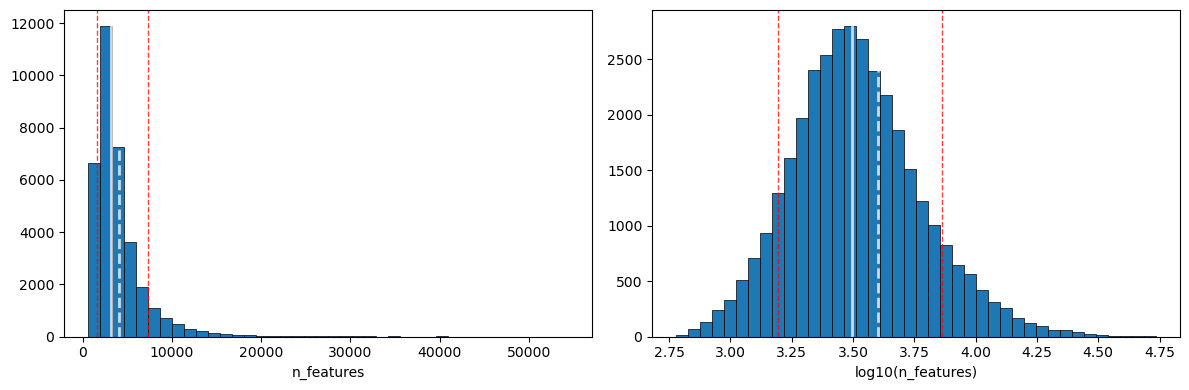

Max:	54366
Median:	3127.5
Mean:	4016.498763443952
Min:	601


In [14]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

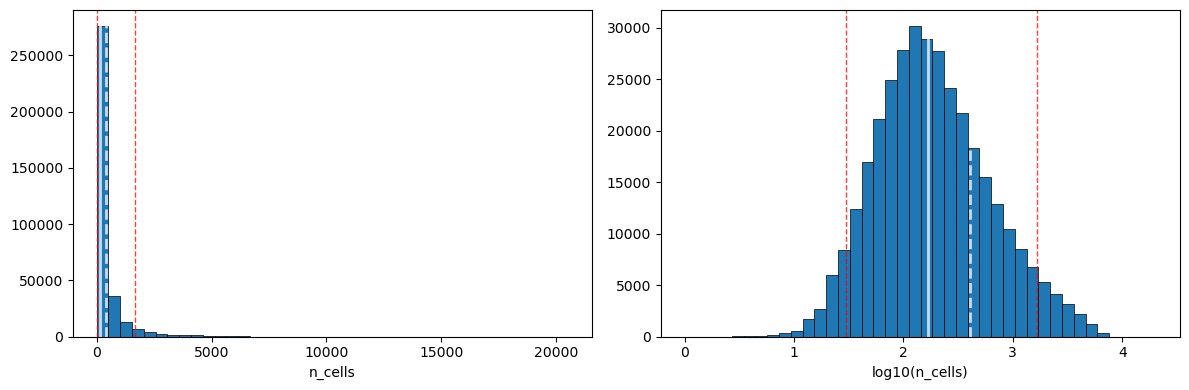

Max:	20519
Median:	168.0
Mean:	405.31912522635463
Min:	1


In [15]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [16]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata

AnnData object with n_obs × n_vars = 27825 × 311181
    obs: 'atac.bc', 'rna.bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'fragment_lengths', 'tss_enrichment'

In [9]:
y_train, y_test = sklearn.model_selection.train_test_split(adata.obs.index,	stratify=adata.obs.celltype, 
                                                            random_state=1, train_size=0.33)
adata=adata[y_train]
adata

View of AnnData object with n_obs × n_vars = 9182 × 311181
    obs: 'atac.bc', 'rna.bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'fragment_lengths', 'tss_enrichment'

In [20]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')

In [27]:
min_var = np.quantile(adata.var.variances_norm, 0.9)
adata=adata[:, adata.var.variances_norm>min_var]
adata

View of AnnData object with n_obs × n_vars = 9182 × 31114
    obs: 'atac.bc', 'rna.bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fragment_lengths', 'tss_enrichment', 'hvg'

In [28]:
epi.pp.normalize_total(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 9182 × 31114
    obs: 'atac.bc', 'rna.bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'fragment_lengths', 'tss_enrichment', 'hvg'

In [31]:
adata.write("Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad", compression="gzip")

## GEX

In [8]:
adata=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_GEX_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 34774 × 23296
    obs: 'atac_bc', 'rna_bc', 'CellType'
    layers: 'raw'

In [3]:
sc.pp.scrublet(adata)

In [4]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1)/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [5]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.925)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.25)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.9)

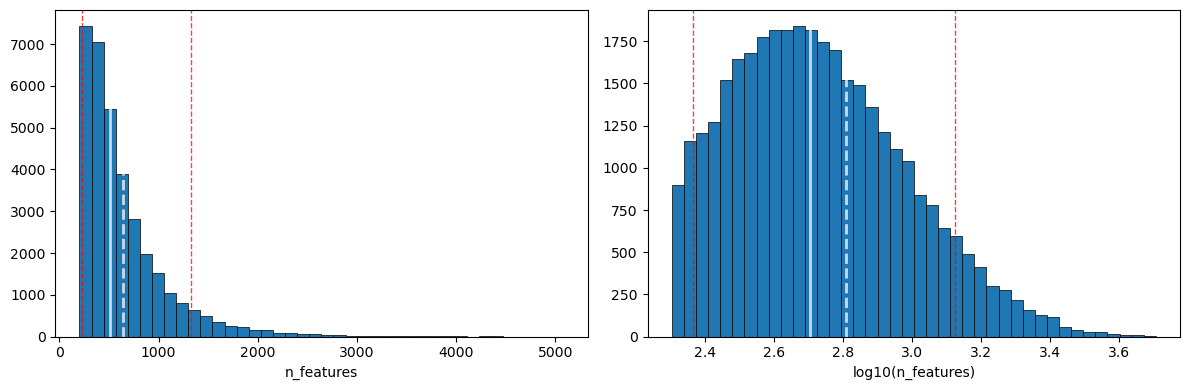

Max:	5079
Median:	506.0
Mean:	642.7239891873238
Min:	201


In [6]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

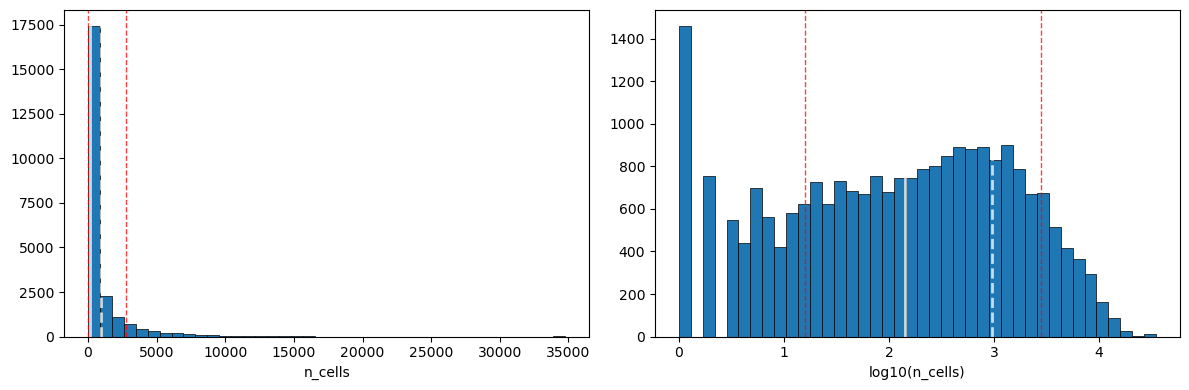

Max:	34774
Median:	141.0
Mean:	959.3957760989011
Min:	0


In [7]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

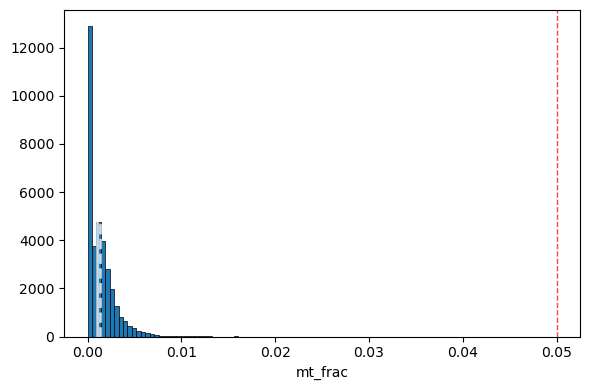

Max:	0.018927445635199547
Median:	0.0010183299891650677
Mean:	0.0013429428217932582
Min:	0.0


In [8]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [9]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 30421 × 15178
    obs: 'atac_bc', 'rna_bc', 'celltype', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [16]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.7)
adata=adata[:, adata.var.variances_norm>min_var]

In [ ]:
subset=list(sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad").obs.index)
adata=adata[intersection([subset, adata.obs.index])]
adata

In [17]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [18]:
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 8429 × 4425
    obs: 'atac_bc', 'rna_bc', 'celltype', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'hvg', 'log1p'

In [19]:
adata.write("Datasets/MouseSkin/CM/MouseSkin_GEX_Def.h5ad", compression="gzip")

## mRNA

In [9]:
adata=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_mRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 34774 × 17106
    obs: 'atac_bc', 'rna_bc', 'CellType'
    layers: 'raw'

In [21]:
sc.pp.scrublet(adata)

In [22]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1)/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [28]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.2)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

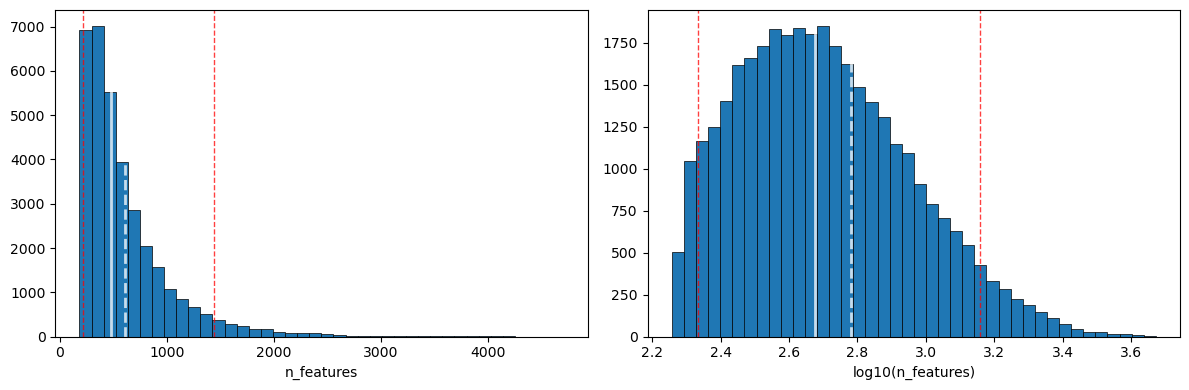

Max:	4703
Median:	475.0
Mean:	603.502386840743
Min:	181


In [24]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

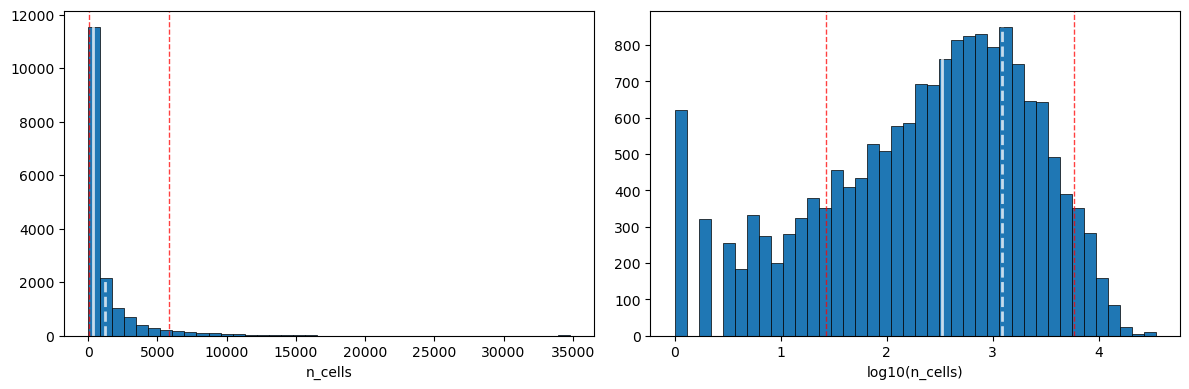

Max:	34771
Median:	332.0
Mean:	1226.832222611949
Min:	0


In [29]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

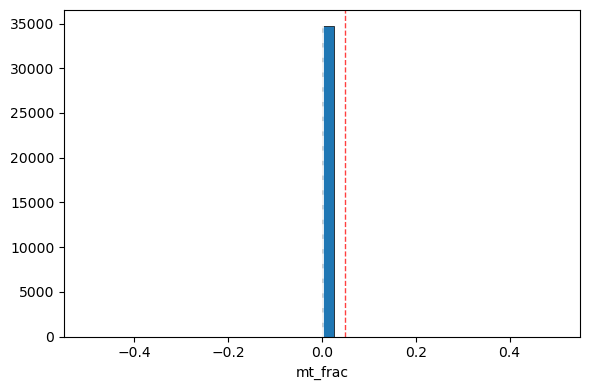

Max:	0.0
Median:	0.0
Mean:	0.0
Min:	0.0


In [30]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [32]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 31359 × 12827
    obs: 'atac_bc', 'rna_bc', 'celltype', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [34]:
subset=list(sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad").obs.index)
adata=adata[intersection([subset, adata.obs.index])]
adata

View of AnnData object with n_obs × n_vars = 8593 × 12827
    obs: 'atac_bc', 'rna_bc', 'celltype', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'scrublet'

In [37]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.6)
adata=adata[:, adata.var.variances_norm>min_var]

In [38]:
adata=adata[:, adata.var.variances_norm>min_var]
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 8593 × 5131
    obs: 'atac_bc', 'rna_bc', 'celltype', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'scrublet', 'hvg', 'log1p'

In [39]:
adata.write("Datasets/MouseSkin/CM/MouseSkin_mRNA_Def.h5ad", compression="gzip")

## lncRNA

In [10]:
adata=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_lncRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
adata

AnnData object with n_obs × n_vars = 34774 × 3868
    obs: 'atac_bc', 'rna_bc', 'CellType'
    layers: 'raw'

In [5]:
epi.pp.qc_stats(adata, verbose=True)

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [6]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.15)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

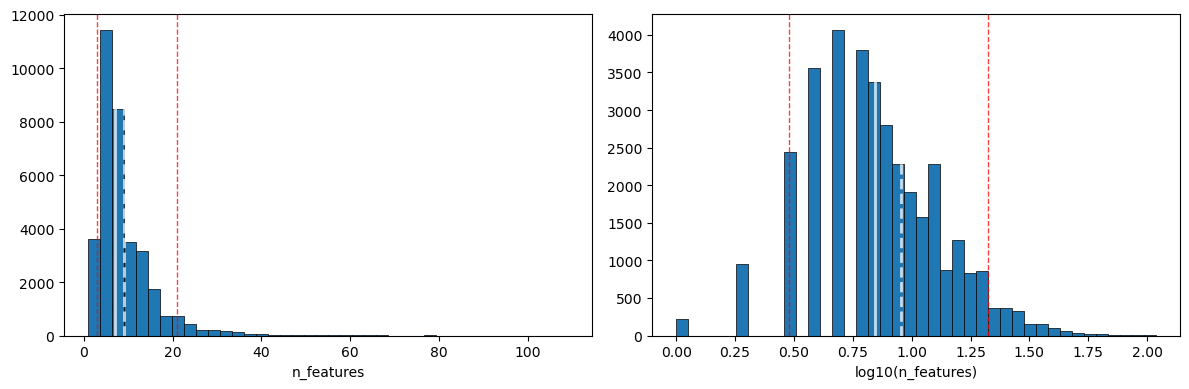

Max:	109
Median:	7.0
Mean:	8.972364410191522
Min:	1


In [7]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

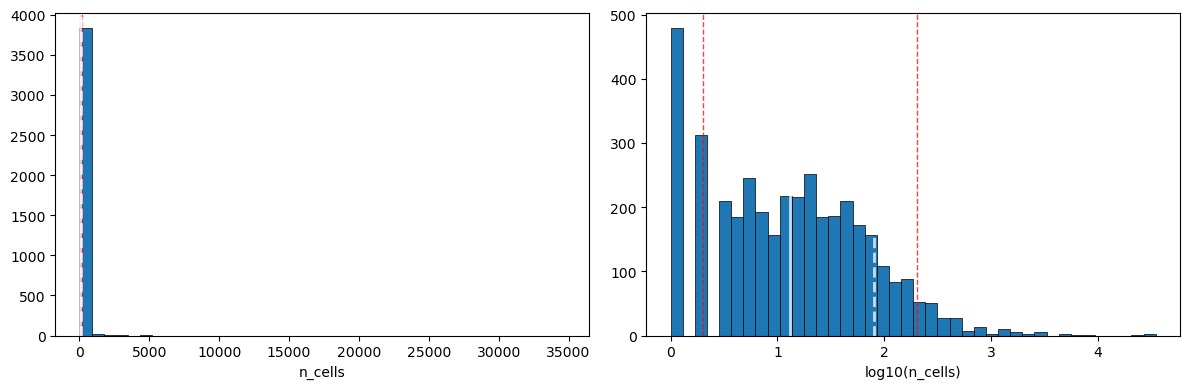

Max:	34720
Median:	13.0
Mean:	80.66313340227508
Min:	0


In [8]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [9]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata

AnnData object with n_obs × n_vars = 31955 × 3196
    obs: 'atac_bc', 'rna_bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter'

In [10]:
subset=list(sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad").obs.index)
adata=adata[intersection([subset, adata.obs.index])]
adata

View of AnnData object with n_obs × n_vars = 8687 × 3196
    obs: 'atac_bc', 'rna_bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter'

In [12]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 7286 × 2648
    obs: 'atac_bc', 'rna_bc', 'celltype', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'

In [13]:
adata.write("Datasets/MouseSkin/CM/MouseSkin_lncRNA_Def.h5ad", compression="gzip")

GEX
mRNA
lncRNA


## Muon objects

In [5]:
import muon as mu
peak=sc.read_h5ad(f"Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad")
gex=sc.read_h5ad(f"Datasets/MouseSkin/CM/MouseSkin_GEX_Def.h5ad")
mrna=sc.read_h5ad(f"Datasets/MouseSkin/CM/MouseSkin_mRNA_Def.h5ad")
lncrna=sc.read_h5ad(f"Datasets/MouseSkin/CM/MouseSkin_lncRNA_Def.h5ad")

#Peak + GEX
print("Peak + GEX")
inter=intersection([peak.obs.index, gex.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "GEX" : gex[inter]})
mudata.write_h5mu(f"Datasets/MouseSkin/CM/MouseSkin_Peak_GEX_Def.h5mu", compression="gzip")

#Peak + mRNA
print("Peak + mRNA")
inter=intersection([peak.obs.index, mrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter]})
mudata.write_h5mu(f"Datasets/MouseSkin/CM/MouseSkin_Peak_mRNA_Def.h5mu", compression="gzip")

#Peak + lncRNA
print("Peak + lncRNA")
inter=intersection([peak.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/MouseSkin/CM/MouseSkin_Peak_lncRNA_Def.h5mu", compression="gzip")

#mRNA + lncRNA
print("mRNA + lncRNA")
inter=intersection([mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/MouseSkin/CM/MouseSkin_mRNA_lncRNA_Def.h5mu", compression="gzip")

#Peak + mRNA + lncRNA
print("Peak + mRNA + lncRNA")
inter=intersection([peak.obs.index, mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/MouseSkin/CM/MouseSkin_Peak_mRNA_lncRNA_Def.h5mu", compression="gzip")

Peak + GEX
Peak + mRNA
Peak + lncRNA
mRNA + lncRNA
Peak + mRNA + lncRNA


# CTA

In [8]:
df=sc.read_h5ad("Datasets/MouseSkin/CM/MouseSkin_Peak_Def.h5ad").obs
df.head()

,atac.bc,rna.bc,CellType,n_features,log_n_features,n_counts,log_n_counts,passes_filter
barcode,,,,,,,,
R1_48_R2_56_R3_41_P1_07,R1_48_R2_56_R3_41_P1_07,R1_48_R2_56_R3_41_P1_55,TAC-2,5843,3.766636,6143.0,3.788381,True
R1_70_R2_10_R3_38_P1_05,R1_70_R2_10_R3_38_P1_05,R1_70_R2_10_R3_38_P1_53,Mix,2182,3.338855,2241.0,3.350442,True
R1_32_R2_36_R3_81_P1_06,R1_32_R2_36_R3_81_P1_06,R1_32_R2_36_R3_81_P1_54,ORS,4350,3.638489,4478.0,3.651084,True
R1_65_R2_16_R3_30_P1_08,R1_65_R2_16_R3_30_P1_08,R1_65_R2_16_R3_30_P1_56,Spinous,3080,3.488551,3158.0,3.499412,True
R1_55_R2_21_R3_55_P1_07,R1_55_R2_21_R3_55_P1_07,R1_55_R2_21_R3_55_P1_55,ahighCD34+ bulge,5241,3.719414,5427.0,3.734560,True


In [11]:
df["RawCelltype"]=df["CellType"]
df["RawCelltype"]=df["RawCelltype"].replace("alowCD34+ bulge", "CD34 bulge")
df["RawCelltype"]=df["RawCelltype"].replace("ahighCD34+ bulge", "CD34 bulge")
df["RawCelltype"]=df["RawCelltype"].replace("TAC-1", "TAC")
df["RawCelltype"]=df["RawCelltype"].replace("TAC-2", "TAC")
df[["CellType","RawCelltype"]].to_csv("Datasets/MouseSkin/MouseSkin_Metadata.tsv.gz", sep="\t", compression="gzip")